# 272. Closest Binary Search Tree Value II
https://leetcode.com/problems/closest-binary-search-tree-value-ii/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| Sort all values | O(n log n) | O(n) | Inorder traversal then sort by distance |
| **Inorder + deque (Optimal)** | **O(n)** | **O(k)** | Inorder traversal with sliding window |

## Methodology

Perform an inorder traversal (which gives sorted values). Maintain a deque of size k. As we traverse, if the deque has fewer than k elements, add the current value. Otherwise, if the current value is closer than the front of the deque, pop from front and add to back. Since values are sorted, once the current value is farther than the front, we can stop early.

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<int> ClosestKValues(TreeNode root, double target, int k) {
        var deque = new LinkedList<int>();
        Inorder(root, target, k, deque);
        return deque.ToList();
    }
    
    private bool Inorder(TreeNode node, double target, int k, LinkedList<int> deque) {
        if (node == null) return false;
        if (Inorder(node.left, target, k, deque)) return true;
        if (deque.Count == k) {
            if (Math.Abs(node.val - target) >= Math.Abs(deque.First.Value - target))
                return true;
            deque.RemoveFirst();
        }
        deque.AddLast(node.val);
        return Inorder(node.right, target, k, deque);
    }
}

### Python

In [ ]:
from collections import deque

class Solution:
    def closestKValues(self, root: Optional[TreeNode], target: float, k: int) -> list[int]:
        dq = deque()
        def inorder(node):
            if not node:
                return False
            if inorder(node.left):
                return True
            if len(dq) == k:
                if abs(node.val - target) >= abs(dq[0] - target):
                    return True
                dq.popleft()
            dq.append(node.val)
            return inorder(node.right)
        inorder(root)
        return list(dq)

### Go

In [ ]:
func closestKValues(root *TreeNode, target float64, k int) []int {
    var result []int
    var inorder func(node *TreeNode) bool
    inorder = func(node *TreeNode) bool {
        if node == nil { return false }
        if inorder(node.Left) { return true }
        if len(result) == k {
            if math.Abs(float64(node.Val)-target) >= math.Abs(float64(result[0])-target) {
                return true
            }
            result = result[1:]
        }
        result = append(result, node.Val)
        return inorder(node.Right)
    }
    inorder(root)
    return result
}

### Rust

In [ ]:
use std::rc::Rc;
use std::cell::RefCell;
use std::collections::VecDeque;

impl Solution {
    pub fn closest_k_values(root: Option<Rc<RefCell<TreeNode>>>, target: f64, k: i32) -> Vec<i32> {
        let mut dq = VecDeque::new();
        Self::inorder(&root, target, k as usize, &mut dq);
        dq.into_iter().collect()
    }
    
    fn inorder(node: &Option<Rc<RefCell<TreeNode>>>, target: f64, k: usize, dq: &mut VecDeque<i32>) -> bool {
        if let Some(n) = node {
            let n = n.borrow();
            if Self::inorder(&n.left, target, k, dq) { return true; }
            if dq.len() == k {
                if (n.val as f64 - target).abs() >= (*dq.front().unwrap() as f64 - target).abs() {
                    return true;
                }
                dq.pop_front();
            }
            dq.push_back(n.val);
            return Self::inorder(&n.right, target, k, dq);
        }
        false
    }
}

## Example Scenarios

1. **Common Case**  
   **Input:** `root = [4,2,5,1,3], target = 3.7, k = 2`  
   Inorder: $[1,2,3,4,5]$. Distances to 3.7: $[2.7, 1.7, 0.7, 0.3, 1.3]$. Closest 2: $\{4, 3\}$.

2. **Slightly Complex**  
   **Input:** `root = [10,5,15,2,7,13,20], target = 8.0, k = 3`  
   Inorder: $[2,5,7,10,13,15,20]$. Closest 3 to 8.0: $\{7, 10, 5\}$. Deque window slides to capture them.

3. **Edge Case: Time Factor**  
   **Input:** $n = 10^4$ nodes in a skewed BST, $k = 10^4$ (return all nodes).  
   Full inorder traversal $O(n)$ with deque never popping. Returns all values.

4. **Edge Case: Space Factor**  
   **Input:** `root = [1], target = 0.0, k = 1`  
   Deque holds at most $k = 1$ element. $O(k) = O(1)$ extra space.

5. **Almost-Impossible but Plausible**  
   **Input:** Balanced BST with $10^4$ nodes, `target = -1000000.0, k = 5`.  
   Target is far left of all values. Deque fills with first 5 inorder values and never pops since distances only increase.

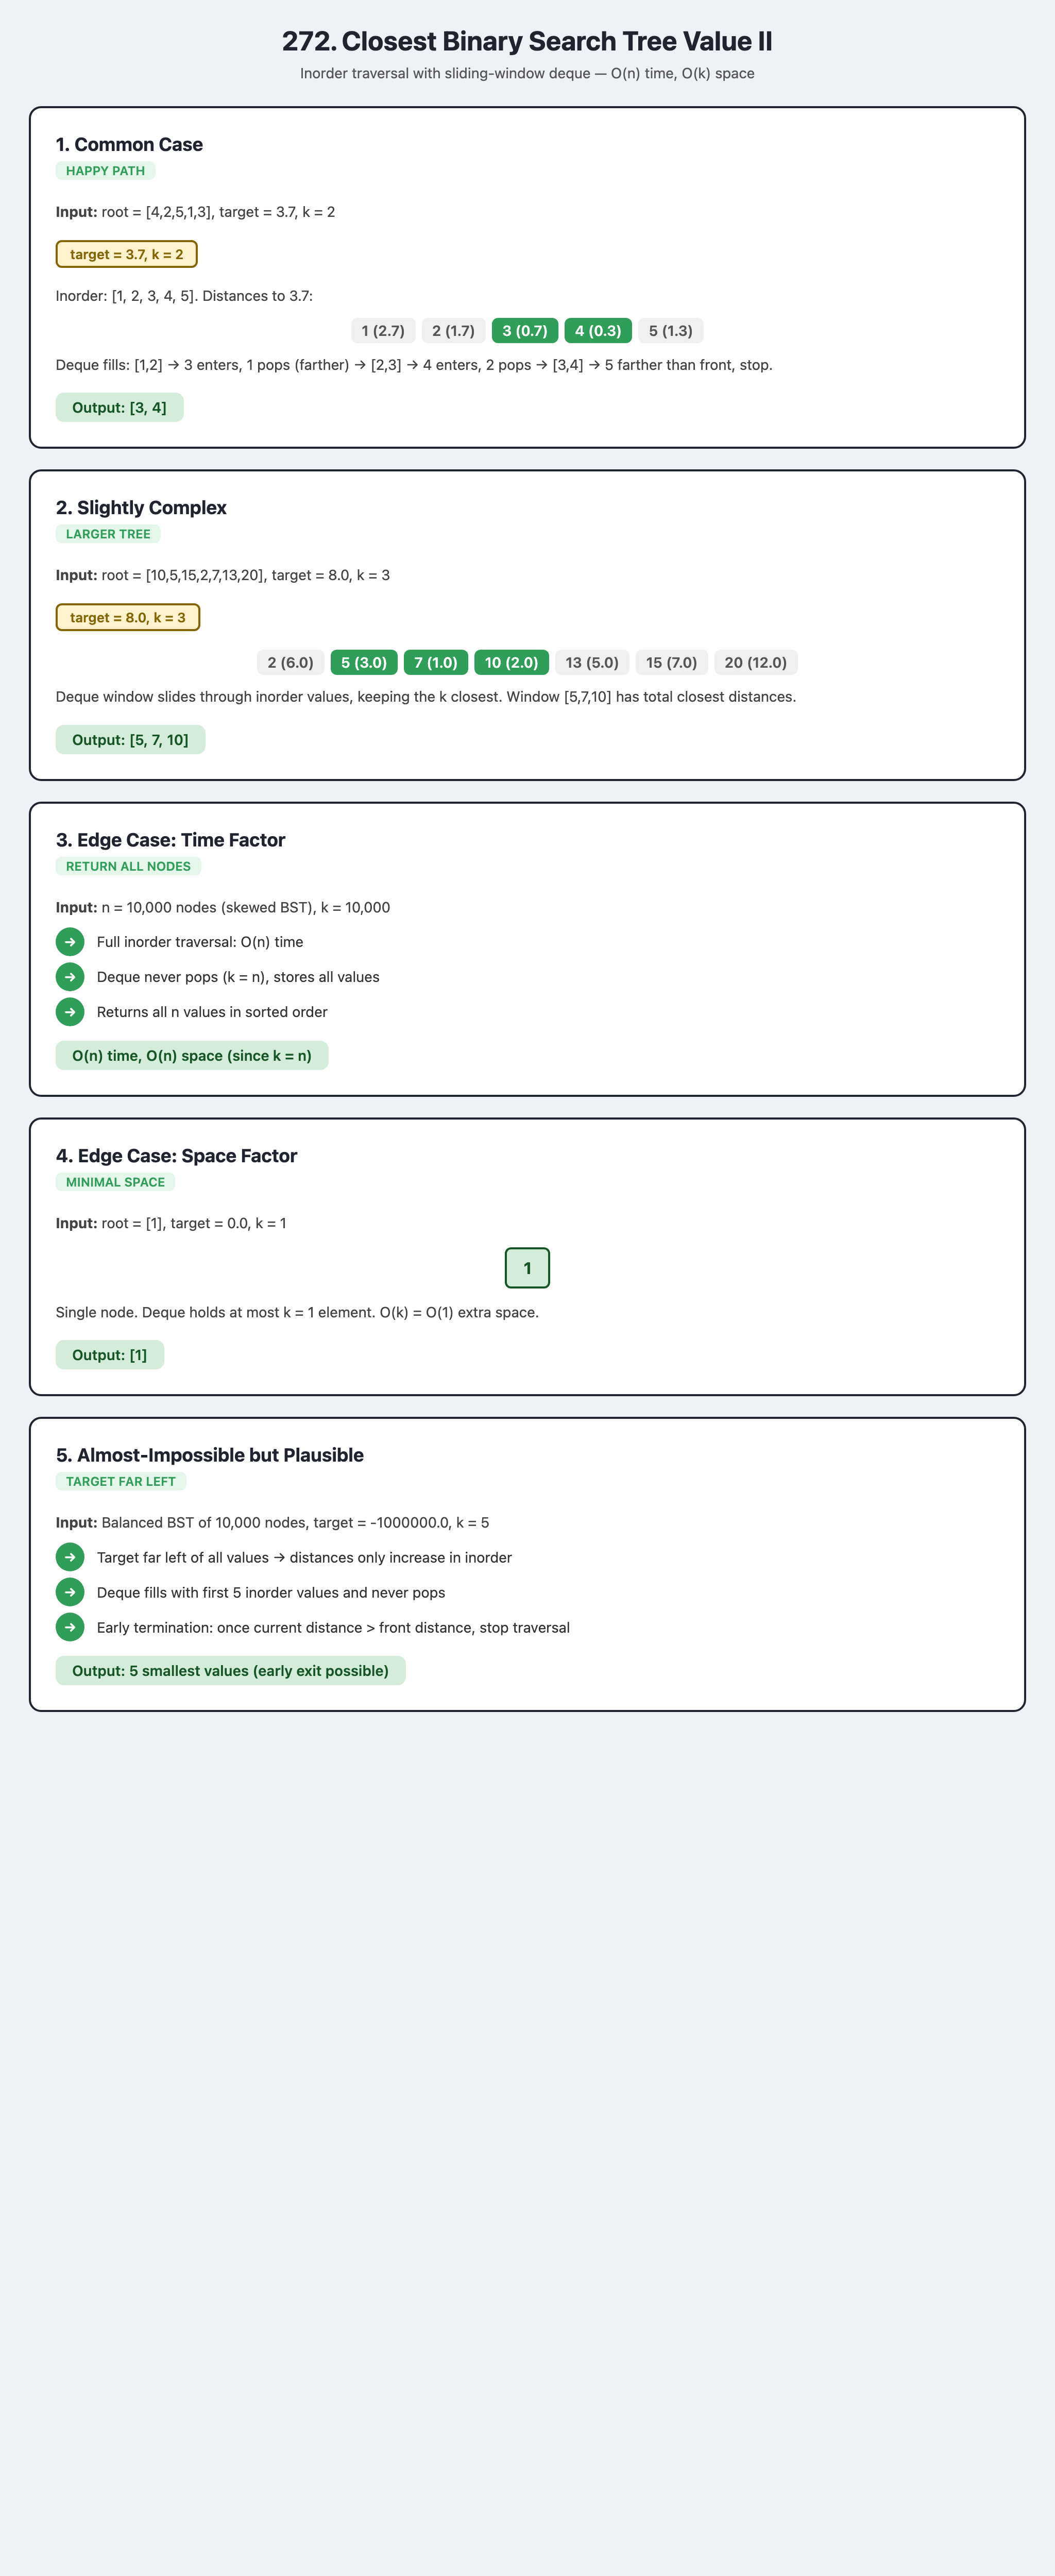